In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [4]:

base_path = (
    "/Users/biancarius/Desktop/"
    "CAETE-DVM-alloc-allom-including_alloc2_Cm2/"
    "paper_resilience/tables_results/"
)

table_2y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_2y.csv"
)
table_2y["Source"] = "2y"

table_4y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_4y.csv"
)
table_4y["Source"] = "4y"

table_6y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_6y.csv"
)
table_6y["Source"] = "6y"

table_8y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_8y.csv"
)
table_8y["Source"] = "8y"

table_regclim = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_regularclimate.csv"
)
table_regclim["Source"] = "regclim"


NameError: name 'pd' is not defined

Combine scenarios

In [3]:

df = pd.concat(
    [table_regclim, table_2y, table_4y, table_6y, table_8y],
    ignore_index=True
)

df["Source"] = pd.Categorical(
    df["Source"],
    categories=["regclim", "8y", "6y", "4y", "2y"],
    ordered=True
)


Transform the year in run year, instead of the date itself 

Build a YEAR -> run_year index PER SCENARIO (0,1,2,3,...)

In [4]:
year_map = (
    df[["Source", "YEAR"]]
    .drop_duplicates()
    .sort_values(["Source", "YEAR"])
    .assign(
        run_year=lambda x: x.groupby("Source").cumcount()
    )
    .reset_index(drop=True)
)


/var/folders/0p/11283pfj6n55yg7pf77flbpc0000gp/T/ipykernel_19459/2116828136.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  run_year=lambda x: x.groupby("Source").cumcount()


In [5]:
#print the head of table df
print(df.head())

   YEAR   PID        OC         g1  sla_random  wd_random   sla_ocp    wd_ocp  \
0  1979  2934  0.015946  11.279744    0.034656   0.371655  0.000553  0.005926   
1  1980  2934  0.003782  11.279744    0.034656   0.371655  0.000131  0.001405   
2  1981  2934  0.014362  11.279744    0.034656   0.371655  0.000498  0.005338   
3  1982  2934  0.016572  11.279744    0.034656   0.371655  0.000574  0.006159   
4  1983  2934  0.019900  11.279744    0.034656   0.371655  0.000690  0.007396   

     g1_ocp   Source  
0  0.179865  regclim  
1  0.042656  regclim  
2  0.162002  regclim  
3  0.186922  regclim  
4  0.224462  regclim  


#  MEAN TEMPORAL SERIES
Here the mean value is calculated using the weight of occupation. 

Otherwise,
the mean would be "puxada" to become bigger or lower depending on the rarity
of strategies


Compute weighted mean per year and scenario (returns NA if sum(OC)==0)

In [6]:
# Helper: weighted mean that returns NaN if total weight is 0/NaN
def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")

    sw = np.nansum(w.values)
    if np.isfinite(sw) and sw > 0:
        return np.nansum((x * w).values) / sw
    return np.nan


trait_means = (
    df.groupby(["Source", "YEAR"], as_index=False)
      .agg(
          sum_OC=("OC", lambda s: np.nansum(pd.to_numeric(s, errors="coerce"))),
          mean_wd=("wd_random", lambda s: weighted_mean(s, df.loc[s.index, "OC"])),
          mean_sla=("sla_random", lambda s: weighted_mean(s * 1000, df.loc[s.index, "OC"])),
          mean_g1=("g1", lambda s: weighted_mean(s, df.loc[s.index, "OC"])),
      )
      .merge(year_map, on=["Source", "YEAR"], how="left")   # left_join
      .sort_values(["Source", "run_year"])                 # arrange
      .reset_index(drop=True)
)

/var/folders/0p/11283pfj6n55yg7pf77flbpc0000gp/T/ipykernel_19459/3920475061.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Source", "YEAR"], as_index=False)


In [7]:


# ============================================================
# COMPUTE RELATIVE DIFFERENCE VS REGCLIM
# rel_diff_% = 100 * (scenario - regclim) / regclim
# aligned by run_year
# ============================================================

# Baseline (regular climate) series by run_year
baseline = (
    trait_means.loc[trait_means["Source"] == "regclim", ["run_year", "mean_wd", "mean_sla", "mean_g1"]]
    .rename(columns={
        "mean_wd": "base_wd",
        "mean_sla": "base_sla",
        "mean_g1": "base_g1"
    })
)

# Join baseline to every scenario by run_year
trait_rel = trait_means.merge(baseline, on="run_year", how="left")

# Compute % change (protect against division by zero if you want)
trait_rel["rel_wd_pct"]  = 100 * (trait_rel["mean_wd"]  - trait_rel["base_wd"])  / trait_rel["base_wd"]
trait_rel["rel_sla_pct"] = 100 * (trait_rel["mean_sla"] - trait_rel["base_sla"]) / trait_rel["base_sla"]
trait_rel["rel_g1_pct"]  = 100 * (trait_rel["mean_g1"]  - trait_rel["base_g1"])  / trait_rel["base_g1"]

# Put in long format for easy faceting
trait_rel_long = (
    trait_rel[["Source", "YEAR", "run_year", "rel_wd_pct", "rel_sla_pct", "rel_g1_pct"]]
    .melt(
        id_vars=["Source", "YEAR", "run_year"],
        var_name="trait",
        value_name="rel_diff_pct"
    )
)

# Recode trait names (like dplyr::recode)
trait_name_map = {
    "rel_wd_pct": "Wood density",
    "rel_sla_pct": "SLA (m²/kg)",
    "rel_g1_pct": "g1",
}
trait_rel_long["trait"] = trait_rel_long["trait"].map(trait_name_map)

# We usually plot only drought scenarios (baseline = 0 line is implicit)
trait_rel_long = trait_rel_long.loc[trait_rel_long["Source"] != "regclim"].reset_index(drop=True)


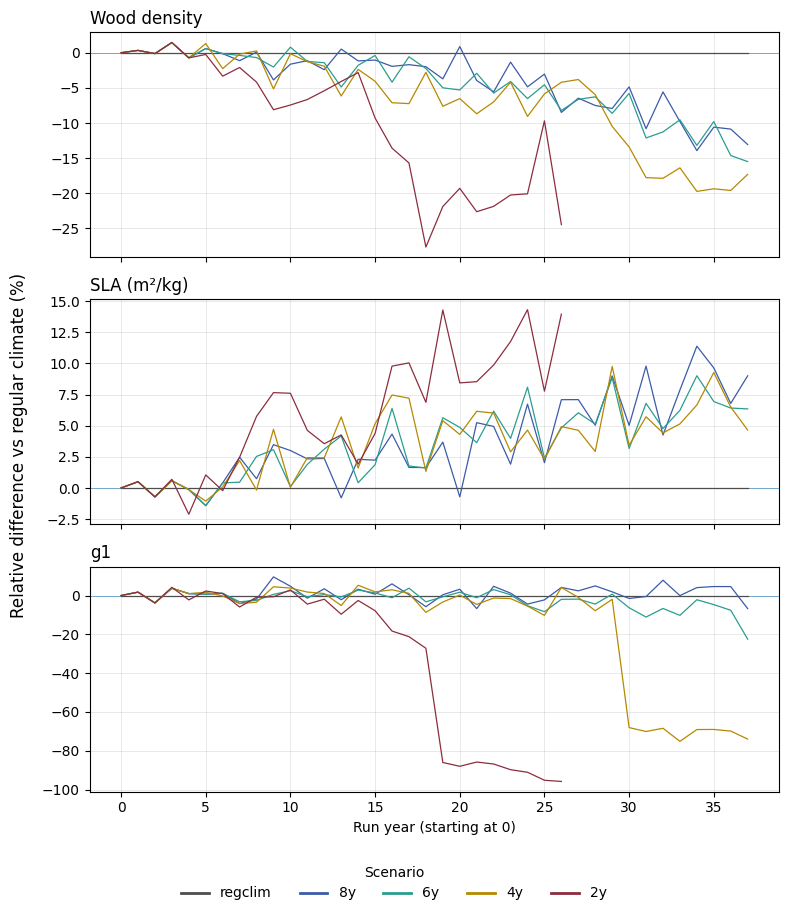

In [8]:


# -----------------------------
# Colors (as requested)
# -----------------------------
freq_colors = {
    "8y": "#3B5BA9",  # blue
    "6y": "#2A9D8F",  # teal
    "4y": "#B58900",  # mustard
    "2y": "#8C2D3E",  # wine
}
colors = {**freq_colors, "regclim": "#4D4D4D"}  # dark gray

source_order = ["regclim", "8y", "6y", "4y", "2y"]

# -----------------------------
# Add regclim as an explicit 0-line series (so it appears in legend)
# -----------------------------
traits_order = ["Wood density", "SLA (m²/kg)", "g1"]
base_xy = trait_means.loc[trait_means["Source"] == "regclim", ["Source", "YEAR", "run_year"]].copy()

baseline_long = pd.concat(
    [
        base_xy.assign(trait=tr, rel_diff_pct=0.0)
        for tr in traits_order
    ],
    ignore_index=True
)

trait_rel_long_plot = pd.concat([trait_rel_long.copy(), baseline_long], ignore_index=True)

# ensure ordering if Source is categorical
if isinstance(trait_rel_long_plot["Source"].dtype, pd.CategoricalDtype):
    trait_rel_long_plot["Source"] = trait_rel_long_plot["Source"].cat.set_categories(source_order, ordered=True)
else:
    trait_rel_long_plot["Source"] = pd.Categorical(trait_rel_long_plot["Source"], categories=source_order, ordered=True)

# -----------------------------
# Plot (facet-like: one axis per trait)
# -----------------------------
fig, axes = plt.subplots(
    nrows=len(traits_order),
    ncols=1,
    figsize=(8, 9),
    sharex=True
)

if len(traits_order) == 1:
    axes = [axes]

for ax, tr in zip(axes, traits_order):
    sub = trait_rel_long_plot.loc[trait_rel_long_plot["trait"] == tr].copy()

    # horizontal 0 line (like geom_hline)
    ax.axhline(0, linewidth=0.4)

    # plot each scenario line
    for src in source_order:
        ss = sub.loc[sub["Source"] == src].sort_values("run_year")
        if ss.empty:
            continue
        ax.plot(
            ss["run_year"],
            ss["rel_diff_pct"],
            linewidth=0.9,
            color=colors.get(src, None),
        )

    # facet label (like facet strip)
    ax.set_title(tr, loc="left")

    # theme-ish
    ax.grid(True, which="major", linewidth=0.5, alpha=0.4)
    ax.minorticks_off()

# axis labels (like labs)
axes[-1].set_xlabel("Run year (starting at 0)")
fig.supylabel("Relative difference vs regular climate (%)")

# legend at bottom
handles = [
    Line2D([0], [0], color=colors[src], lw=2, label=src)
    for src in source_order
    if src in trait_rel_long_plot["Source"].astype(str).unique()
]
fig.legend(
    handles=handles,
    title="Scenario",
    loc="lower center",
    ncol=len(handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


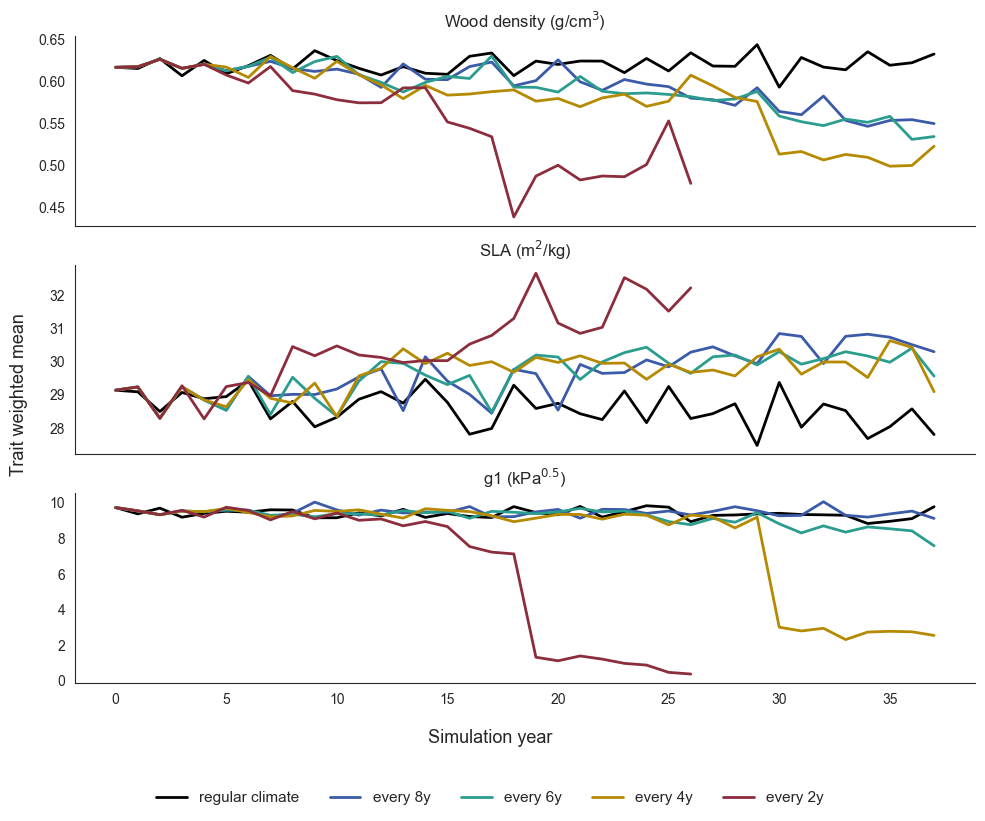

In [9]:

import seaborn as sns


# -----------------------------
# Colors (user-specified)
# -----------------------------
freq_colors = {
    # "regclim": "#4D4D4D",
    "regclim": "#000000",	
    "8y": "#3B5BA9",
    "6y": "#2A9D8F",
    "4y": "#B58900",
    "2y": "#8C2D3E",
}
order = ["regclim", "8y", "6y", "4y", "2y"]


# -----------------------------
# Traits to plot
# -----------------------------
traits = ["mean_wd", "mean_sla", "mean_g1"]
traits_label = {
    "mean_wd": r"Wood density (g/cm$^3$)",
    "mean_sla": r"SLA (m$^2$/kg)",
    "mean_g1": r"g1 (kPa$^{0.5}$)",
}

# -----------------------------
# Plot settings (clean, Nature-like)
# -----------------------------
sns.set_style("white")

fig, axes = plt.subplots(
    nrows=len(traits), ncols=1,
    figsize=(10, 8),
    sharex=True,
    sharey=False
)

if len(traits) == 1:
    axes = [axes]

# max run_year for ticks
max_run = int(trait_means["run_year"].max())

# -----------------------------
# Draw each trait in its own panel
# -----------------------------
for ax, tr in zip(axes, traits):

    # drought scenarios
    for sc in order:
    	df_sc = trait_means.loc[trait_means["Source"] == sc].copy()
    	sns.lineplot(
        	data=df_sc,
        	x="run_year",
        	y=tr,
        	ax=ax,
        	linewidth=2.0,
        	label=sc,
        	color=freq_colors[sc],
    )

    ax.set_title(traits_label[tr], fontsize=12)
    ax.grid(False)
    sns.despine(ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # remove per-axis legend (we'll make a shared one)
    if ax.get_legend() is not None:
        ax.legend_.remove()

# -----------------------------
# Common axis labels
# -----------------------------
fig.supxlabel("Simulation year", fontsize=13, y=0.06)
fig.supylabel("Trait weighted mean", fontsize=13)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_run + 1, 5))

# -----------------------------
# One shared legend (frequencies)
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

label_map = {
    "regclim": "regular climate",
    "8y": "every 8y",
    "6y": "every 6y",
    "4y": "every 4y",
    "2y": "every 2y",
}

labels = [label_map.get(l, l) for l in labels]

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)  # space for legend
plt.show()


/var/folders/0p/11283pfj6n55yg7pf77flbpc0000gp/T/ipykernel_19459/3733976585.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


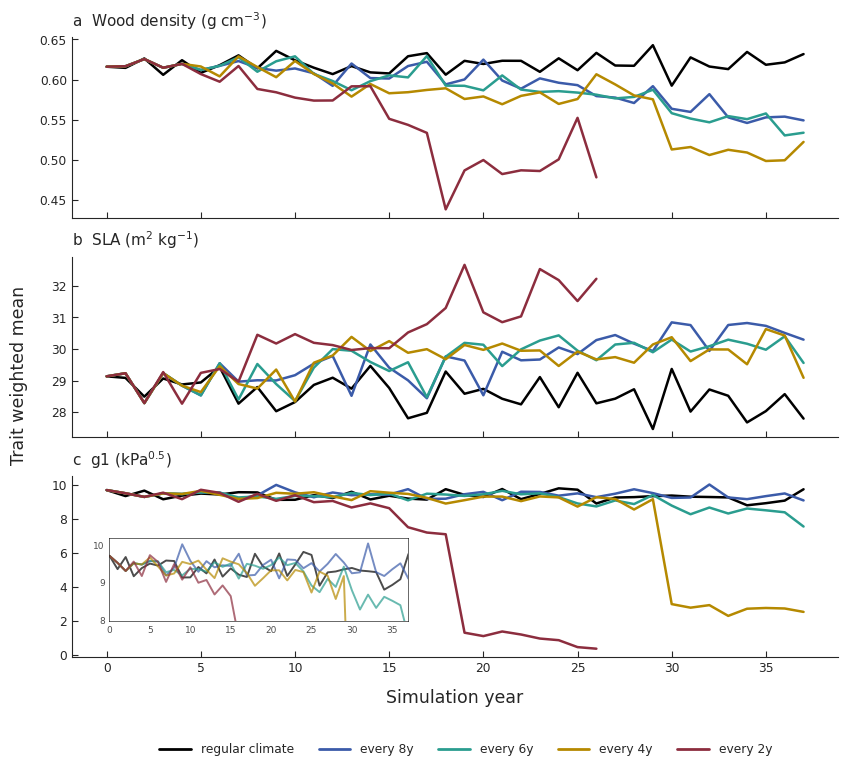

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sns.set_style("white")
sns.set_context("paper", font_scale=1.0)

# rcParams mais "journal"
plt.rcParams.update({
    "font.family": "DejaVu Sans",   # se tiver Arial/Helvetica instalado, melhor ainda
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

freq_colors = {
    "regclim": "#000000",
    "8y": "#3B5BA9",
    "6y": "#2A9D8F",
    "4y": "#B58900",
    "2y": "#8C2D3E",
}
order = ["regclim", "8y", "6y", "4y", "2y"]

traits = ["mean_wd", "mean_sla", "mean_g1"]
traits_label = {
    "mean_wd": r"Wood density (g cm$^{-3}$)",
    "mean_sla": r"SLA (m$^2$ kg$^{-1}$)",
    "mean_g1": r"g1 (kPa$^{0.5}$)",
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8.6, 7.6), sharex=True)
max_run = int(trait_means["run_year"].max())

panel_letters = ["a", "b", "c"]

for i, (ax, tr) in enumerate(zip(axes, traits)):

    for sc in order:
        df_sc = trait_means.loc[trait_means["Source"] == sc].sort_values("run_year")
        if df_sc.empty:
            continue

        lw = 1.8 if sc == "regclim" else 1.8
        ax.plot(
            df_sc["run_year"], df_sc[tr],
            color=freq_colors[sc],
            linewidth=lw,
            solid_capstyle="round",
            label=sc
        )

    # título no canto, estilo facet
    ax.text(
        0.0, 1.03,
        f"{panel_letters[i]}  {traits_label[tr]}",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=11
    )

    ax.grid(False)
    sns.despine(ax=ax)

    # ticks visíveis e consistentes
    ax.tick_params(bottom=True, left=True, labelleft=True)

# eixo x (menos poluído)
xticks = [0, 5, 10, 15, 20, 25, 30, 35]
axes[-1].set_xticks(xticks)
axes[-1].set_xlabel("Simulation year", labelpad=10, fontsize=12.5)

# ylabel global
fig.supylabel("Trait weighted mean", x=0.02, fontsize=12.5)

# legenda única embaixo, em ordem fixa
label_map = {
    "regclim": "regular climate",
    "8y": "every 8y",
    "6y": "every 6y",
    "4y": "every 4y",
    "2y": "every 2y",
}
legend_handles = [Line2D([0], [0], color=freq_colors[k], lw=2.0 if k=="regclim" else 2.0) for k in order]
legend_labels  = [label_map[k] for k in order]

fig.legend(
    legend_handles, legend_labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.55, -0.015),
    handlelength=2.6
)

# -------- Optional (recomendado): inset zoom no g1 --------
# zoom para ver as séries "normais" sem o colapso esmagar o resto
# -------- Inset zoom no g1 (tudo translúcido) --------
ax_g1 = axes[2]

ins = inset_axes(ax_g1, width="39%", height="46%", loc="lower left", bbox_to_anchor=(0.03, 0.12, 1, 1),   # (x0, y0, width_ref, height_ref)
    bbox_transform=ax_g1.transAxes, borderpad=1.2)

# controle geral de "translucidez"
INSET_ALPHA = 0.70

# fundo + borda translúcidos
ins.set_facecolor("white")          # mantém legível
ins.patch.set_alpha(INSET_ALPHA)    # transparência do fundo
for spine in ins.spines.values():
    spine.set_alpha(INSET_ALPHA)
    spine.set_linewidth(0.7)

# linhas translúcidas
for sc in order:
    df_sc = trait_means.loc[trait_means["Source"] == sc].sort_values("run_year")
    if df_sc.empty:
        continue
    ins.plot(
        df_sc["run_year"], df_sc["mean_g1"],
        color=freq_colors[sc],
        linewidth=1.4,
        alpha=INSET_ALPHA,          # transparência das linhas
        solid_capstyle="round",
    )

ins.set_ylim(8.0, 10.2)
ins.set_xlim(0, max_run)

# ticks e labels translúcidos
ins.tick_params(
    labelsize=6.5,
    direction="in",
    length=3,
    width=0.7,
    colors=(0, 0, 0, INSET_ALPHA)   # aplica alpha ao texto e aos ticks
)

# (opcional) deixar também os números do tick com alpha garantido
for lab in ins.get_xticklabels() + ins.get_yticklabels():
    lab.set_alpha(INSET_ALPHA)


plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()


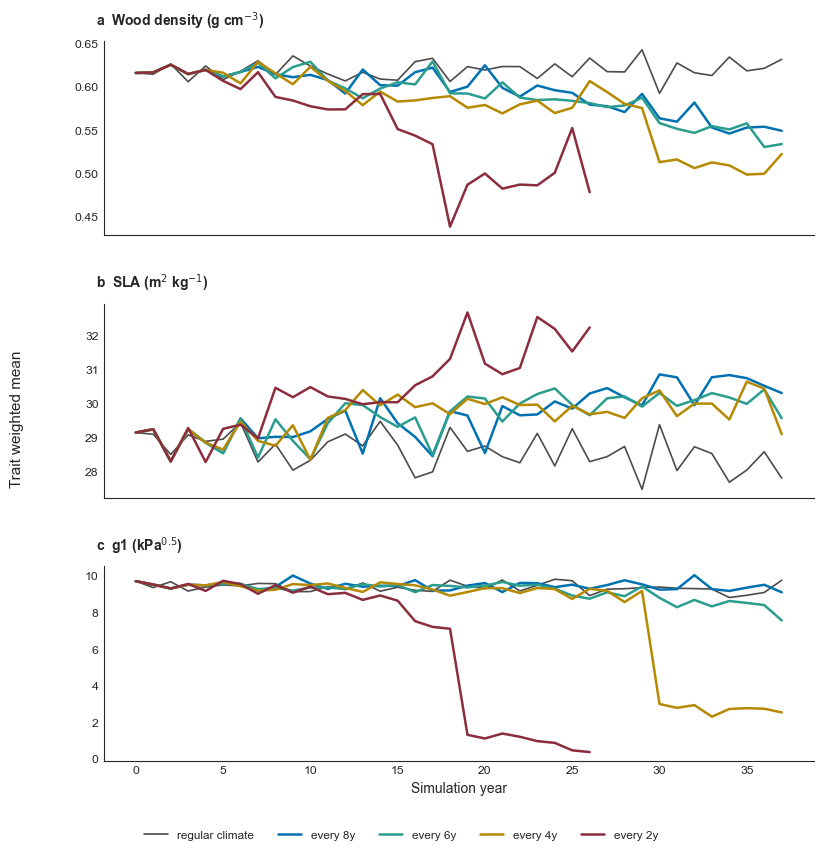

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Global font configuration for Nature (Arial/Helvetica)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 8 

# ---------------------------------------------------------
# 2. Setup Data from your 'trait_means' dataframe
# ---------------------------------------------------------
# Filtering your consolidated dataframe into a dictionary for the loop
# Source names in your notebook: 'regclim', '8y', '6y', '4y', '2y'
scenarios_traits = {
    "regular": trait_means[trait_means["Source"] == "regclim"],
    "8y": trait_means[trait_means["Source"] == "8y"],
    "6y": trait_means[trait_means["Source"] == "6y"],
    "4y": trait_means[trait_means["Source"] == "4y"],
    "2y": trait_means[trait_means["Source"] == "2y"],
}

order_traits = ["regular", "8y", "6y", "4y", "2y"]

# Mapping your column names to labels
# wd_random -> Wood density; sla_random -> SLA; g1 -> g1
trait_vars = ["mean_wd", "mean_sla", "mean_g1"]
trait_labels = {
    "mean_wd": "Wood density (g cm$^{-3}$)",
    "mean_sla": "SLA (m$^{2}$ kg$^{-1}$)",
    "mean_g1": "g1 (kPa$^{0.5}$)"
}

freq_colors_traits = {
    "regular": "#000000", # Black for baseline
    "8y": "#0072B2",      # Blue
    "6y": "#2A9D8F",      # Teal
    "4y": "#B58900",      # Mustard
    "2y": "#8C2D3E",      # Wine
}

label_map_traits = {
    "regular": "regular climate",
    "8y": "every 8y",
    "6y": "every 6y",
    "4y": "every 4y",
    "2y": "every 2y"
}

# ---------------------------------------------------------
# 3. Plotting
# ---------------------------------------------------------
sns.set_style("white")

fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(8.5, 9), 
    sharex=True
)

panel_labels = ["a", "b", "c"]
# Using run_year from your trait_means as the X axis
max_year = int(trait_means["run_year"].max())

for i, (ax, var) in enumerate(zip(axes, trait_vars)):
    
    for sc in order_traits:
        df_sc = scenarios_traits[sc]
        x_data = df_sc["run_year"]
        y_data = df_sc[var]

        # Plotting lines with a slight distinction for the baseline
        ax.plot(
            x_data, 
            y_data, 
            color=freq_colors_traits[sc], 
            linewidth=1.8 if sc != "regular" else 1.2,
            label=label_map_traits[sc],
            alpha=1 if sc != "regular" else 0.7,
            zorder=10 if sc != "regular" else 5
        )

    # --- Nature-style labels: Bold identifier and trait name ---
    ax.text(-0.01, 1.05, f"{panel_labels[i]}  {trait_labels[var]}", 
            transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
    
    sns.despine(ax=ax)
    ax.tick_params(direction='in', length=4)

# Centralized Y-axis label
fig.text(0.04, 0.5, 'Trait weighted mean', va='center', rotation='vertical', fontsize=11)

# X-axis cleanup using run_year
axes[-1].set_xlabel("Simulation year", fontsize=10)
axes[-1].set_xticks(range(0, max_year + 1, 5))

# Shared Legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=8.5,
    bbox_to_anchor=(0.5, 0.02)
)

plt.tight_layout()
# Adjust margins for labels and legend
plt.subplots_adjust(left=0.15, bottom=0.12, hspace=0.35, top=0.92)

plt.show()